In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import healpy as hp

In [2]:
NSIDE = 4096
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 4096 is 0.014 deg


In [3]:
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

201326592


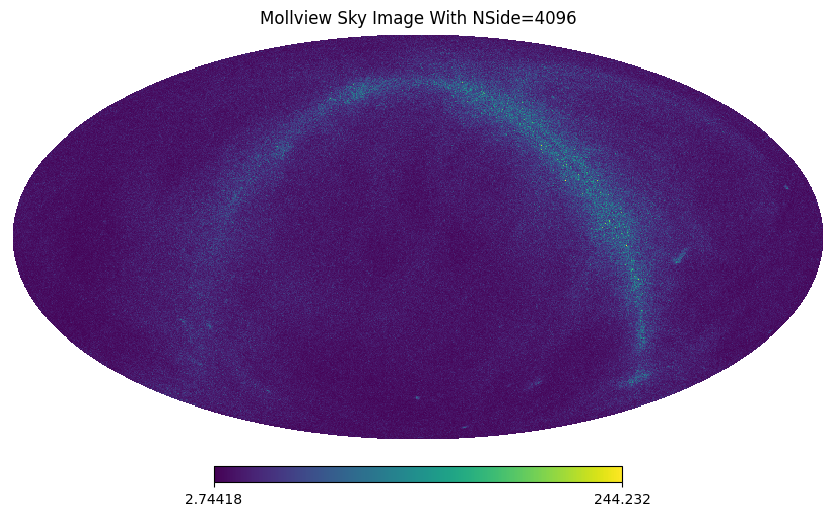

In [5]:
# recon = np.fromfile("./earth_10Mhz/sky_10MHz_n4096.bin", dtype=np.float32)
recon = np.fromfile("./earth_10Mhz/sky_30MHz_n16384.bin", dtype=np.float32)

hp.mollview(recon, 
            nest=True, 
            title="Mollview Sky Image With NSide=4096")
plt.show()

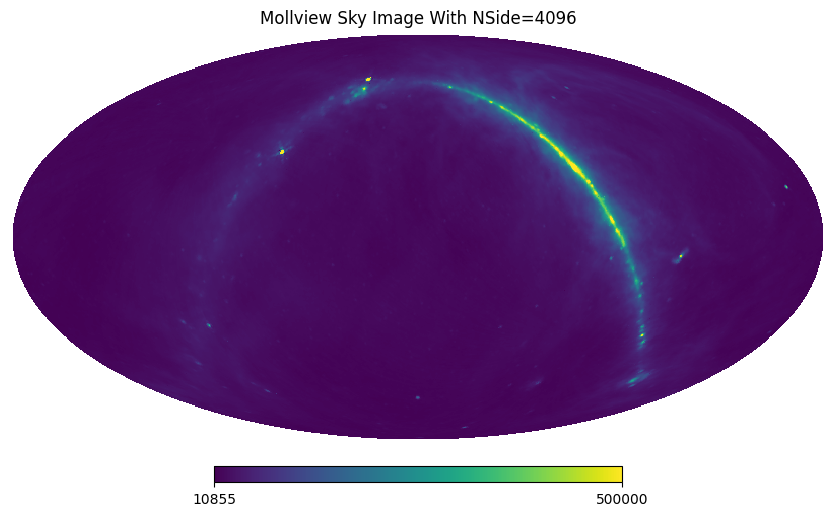

In [ ]:
original_image = np.loadtxt("./earth_10Mhz/B_10Mhz_changeMin.txt")


hp.mollview(original_image, 
            nest=True, 
            title="Mollview Sky Image With NSide=4096")
plt.show()

In [9]:
output_path = "./earth_10Mhz/B_10M.bin"
original_image = original_image.astype(np.float32)

# 使用 tofile 保存为原始二进制格式（与 np.fromfile 配对使用）
original_image.tofile(output_path)

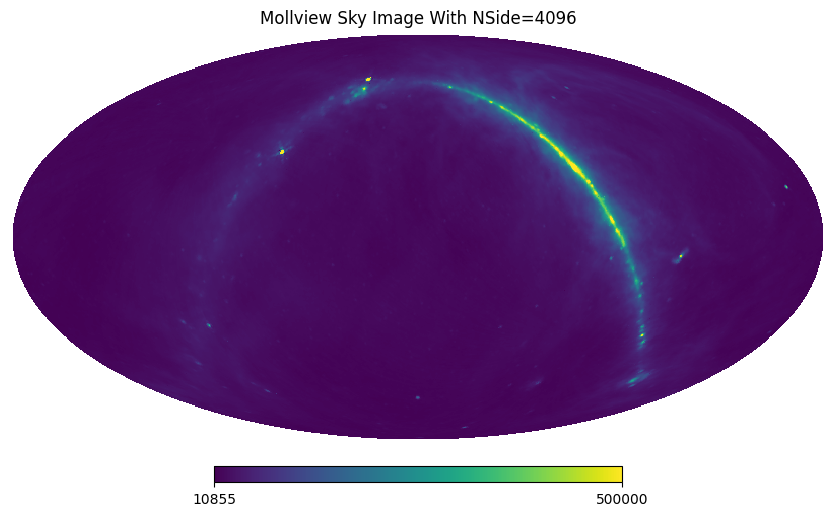

In [10]:
recon_mirror_image = np.fromfile(output_path, dtype=np.float32)

hp.mollview(recon_mirror_image, 
            nest=True, 
            title="Mollview Sky Image With NSide=4096")
plt.show()

# 差值到30Mhz

原始数据长度: 201326592
期望长度 (NSIDE=4096): 201326592


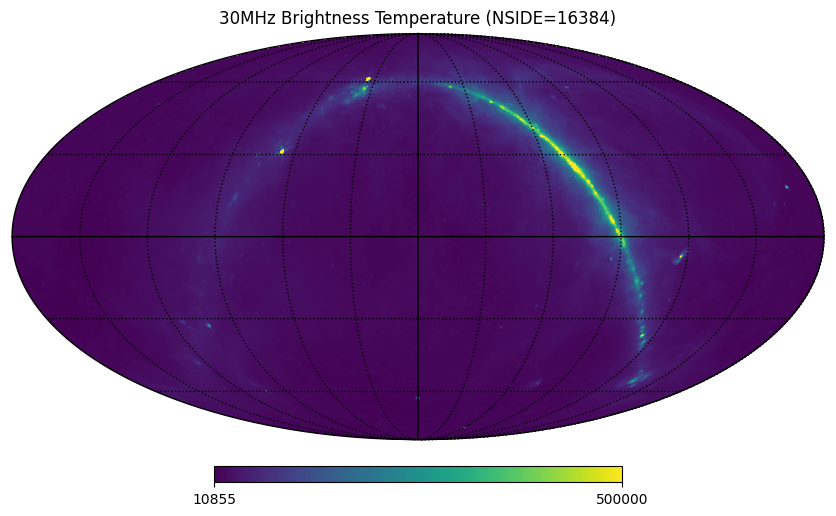

In [12]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import os

# 1. 读取原始数据
original_image = np.loadtxt("./earth_10Mhz/B_10Mhz_changeMin.txt")

# 2. 基本参数
nside_in = 4096
nside_out = 16384
expected_npix_in = hp.nside2npix(nside_in)   # 201,326,592
expected_npix_out = hp.nside2npix(nside_out) # 3,221,225,472

print(f"原始数据长度: {len(original_image)}")
print(f"期望长度 (NSIDE={nside_in}): {expected_npix_in}")

# 3. 确保数据类型和形状正确
original_image = original_image.astype(np.float64)  # ud_grade 推荐用 float64 避免精度问题

# 4. 使用 ud_grade 提升分辨率（nest 排序下非常快）
# nside 从 4096 -> 16384，提升了 4 倍（2^2），每个像素分裂为 16 个子像素
image_30M_nest = hp.ud_grade(original_image, nside_out=nside_out, order_in='NESTED', order_out='NESTED')

# 5. 确保亮温不为负（裁剪到 >= 0）
image_30M_nest = np.clip(image_30M_nest, a_min=0, a_max=None)

# 6. 转换为 float32 并保存
image_30M_nest = image_30M_nest.astype(np.float32)

hp.mollview(image_30M_nest, nest=True, title="30MHz Brightness Temperature (NSIDE=16384)", xsize=2000)
hp.graticule()
plt.show()

原始数据长度: 201326592
期望输入长度: 201326592
输出像素数: 3221225472

步骤1: ud_grade 到 NSIDE=8192...
NSIDE=8192 数据长度: 805306368

步骤2: 手动插值 8192 -> 16384...
计算邻居和插值...
插值完成，输出长度: 3221225472


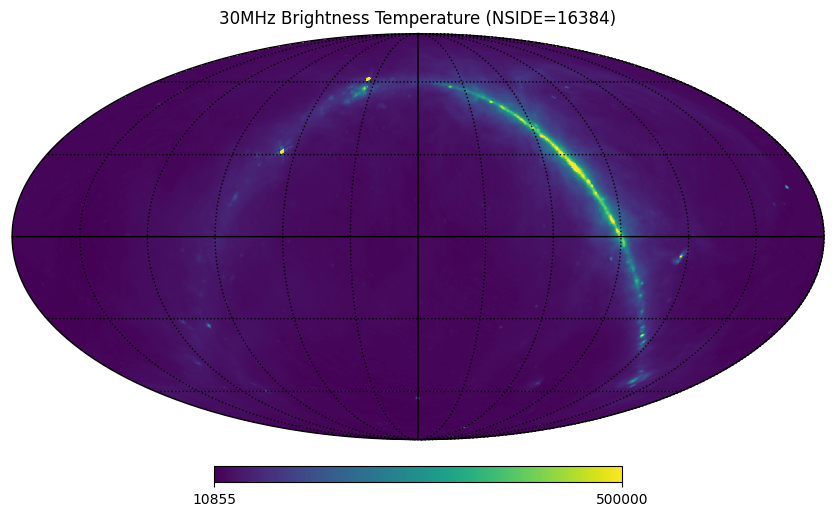

In [15]:

# ============ 2. 参数设置 ============
nside_in = 4096
nside_out = 16384
npix_in = hp.nside2npix(nside_in)      # 201,326,592
npix_out = 12 * nside_out**2           # 3,221,225,472 (healpy 不支持，手动计算)

print(f"原始数据长度: {len(original_image)}")
print(f"期望输入长度: {npix_in}")
print(f"输出像素数: {npix_out}")

# 验证输入数据
assert len(original_image) == npix_in, f"数据长度不匹配: {len(original_image)} != {npix_in}"

# ============ 3. 方法：基于 NESTED 层级结构的局部插值 ============
# NSIDE 4096 -> 16384，每个像素分裂为 4 个子像素
# 在 NESTED 排序下，子像素索引 = 父像素索引 * 4 + [0,1,2,3]

# 方案A: 简单复制（每个子像素=父像素值）- 你之前觉得不行
# 方案B: 添加微小随机扰动或梯度（不推荐，不物理）
# 方案C: 利用相邻父像素做双线性插值

# 这里用方案C的简化版：利用 NESTED 索引的局部性
# 对于每个父像素，计算其4个子像素的中心位置，然后基于相邻父像素做插值

# 由于 healpy 不支持 nside=16384，我们用 astropy_healpix 或手动计算
# 但更简单的方法是：先 ud_grade 到 nside=8192（healpy支持的最大值），
# 然后手动再提升一倍到 16384

# ============ 步骤1: ud_grade 到 8192 ============
print("\n步骤1: ud_grade 到 NSIDE=8192...")
image_8192 = hp.ud_grade(
    original_image.astype(np.float64), 
    nside_out=8192, 
    order_in='NESTED', 
    order_out='NESTED'
)
print(f"NSIDE=8192 数据长度: {len(image_8192)}")

# ============ 步骤2: 手动从 8192 -> 16384 ============
# 每个 8192 像素分裂为 4 个 16384 子像素
# 在 NESTED 排序下，子像素是连续的

print("\n步骤2: 手动插值 8192 -> 16384...")

npix_8192 = len(image_8192)
npix_16384 = 12 * nside_out**2

# 预分配输出数组
image_30M = np.empty(npix_16384, dtype=np.float64)

# NESTED 排序的层级关系：
# 父像素索引 i (at nside=8192) 的4个子像素索引为：4*i, 4*i+1, 4*i+2, 4*i+3

# 为了做有变化的插值，我们需要知道每个子像素的空间位置
# 以及相邻父像素的值

# 方法：对于每个子像素，根据其相对于父像素中心的位置，
# 结合相邻父像素的值做双线性插值

# 由于 healpy 不支持 nside=16384，我们用以下近似：
# 利用 NESTED 索引的位运算特性来找到相邻像素

def get_neighbours_nest(nside, ipix):
    """
    获取 NESTED 排序下像素的8个邻居
    使用 healpy 的 get_all_neighbours（仅支持 nside <= 8192）
    这里对 nside=8192 的父像素使用
    """
    return hp.get_all_neighbours(nside, ipix, nest=True)

# 对于每个 8192 像素，获取其值和邻居值
# 然后对其 4 个子像素分别赋予插值后的值

# 优化：向量化处理
print("计算邻居和插值...")

# 获取所有 8192 像素的邻居
# neighbors shape: (8, npix_8192)
neighbors = hp.get_all_neighbours(8192, np.arange(npix_8192), nest=True)

# 处理边界（-1 表示无邻居，用自身值代替）
neighbor_values = np.where(neighbors >= 0, image_8192[neighbors], image_8192[np.newaxis, :])

# 计算每个 8192 像素及其邻居的平均值（用于平滑）
# 使用4个主要方向（N, S, E, W）的平均
smooth_8192 = (image_8192 + 
               neighbor_values[0] + neighbor_values[2] + 
               neighbor_values[4] + neighbor_values[6]) / 5.0
# 处理边界上的 -1
smooth_8192 = np.nan_to_num(smooth_8192, nan=image_8192)

# 现在为每个 8192 像素的 4 个子像素赋值
# 子像素排列（NESTED）：
#  0 | 1
#  ---+---
#  2 | 3

# 使用父像素值和邻居值做简单的双线性插值
# 子像素 0: 偏向西北 (父 + 北邻居 + 西邻居 + 西北邻居) / 4
# 子像素 1: 偏向东北 (父 + 北邻居 + 东邻居 + 东北邻居) / 4  
# 子像素 2: 偏向西南 (父 + 南邻居 + 西邻居 + 西南邻居) / 4
# 子像素 3: 偏向东南 (父 + 南邻居 + 东邻居 + 东南邻居) / 4

# 获取方向邻居（NESTED顺序：N=0, NE=1, E=2, SE=3, S=4, SW=5, W=6, NW=7）
n = neighbor_values[0]   # North
ne = neighbor_values[1]  # Northeast
e = neighbor_values[2]   # East
se = neighbor_values[3]  # Southeast
s = neighbor_values[4]   # South
sw = neighbor_values[5]  # Southwest
w = neighbor_values[6]   # West
nw = neighbor_values[7]  # Northwest

# 为4个子像素分别计算插值
# 使用父像素和直接邻居的加权平均
sub_0 = (2*image_8192 + n + w) / 4.0  # 西北
sub_1 = (2*image_8192 + n + e) / 4.0  # 东北
sub_2 = (2*image_8192 + s + w) / 4.0  # 西南
sub_3 = (2*image_8192 + s + e) / 4.0  # 东南

# 填充到输出数组
indices = np.arange(npix_8192)
image_30M[4*indices + 0] = sub_0
image_30M[4*indices + 1] = sub_1
image_30M[4*indices + 2] = sub_2
image_30M[4*indices + 3] = sub_3

print(f"插值完成，输出长度: {len(image_30M)}")

# ============ 4. 确保亮温不为负 ============
image_30M = np.clip(image_30M, a_min=0, a_max=None)

# ============ 5. 转换为 float32 并保存 ============
image_30M = image_30M.astype(np.float32)


hp.mollview(image_30M, nest=True, title="30MHz Brightness Temperature (NSIDE=16384)", xsize=2000)
hp.graticule()
plt.show()


In [16]:

output_path = "./B_30M.bin"
image_30M.tofile(output_path)

print(f"\n已保存: {output_path}")
print(f"文件大小: {os.path.getsize(output_path) / 1024**3:.2f} GB")
print(f"输出数据范围: [{image_30M.min():.2f}, {image_30M.max():.2f}]")



已保存: ./B_30M.bin
文件大小: 12.00 GB
输出数据范围: [10855.00, 500000.00]


In [ ]:
# ============ 6. 验证加载 ============
recon = np.fromfile(output_path, dtype=np.float32)
print(f"\n加载验证:")
print(f"  长度: {len(recon)}")
print(f"  范围: [{recon.min():.2f}, {recon.max():.2f}]")
print(f"  数据一致: {np.allclose(image_30M, recon)}")


hp.mollview(recon, nest=True, title="30MHz Brightness Temperature (NSIDE=16384)", xsize=2000)
hp.graticule()
plt.show()

plt.tight_layout()
plt.savefig("comparison_interpolated.png", dpi=150)

print("\n完成！")